# GD-1 streamTrack: smoothing-factor comparison

Take the GD-1-I21 setup from the galstreams stress test (mass ≈
2.5 × 10⁴ M☉, t_disrupt ≈ 2.9 Gyr in `MWPotential2014`), sample particles
**once**, then refit `streamTrack` at `smoothing_factor` ∈ {0.25, 1, 4}
using the particle-reuse handle (`track.particles`). Because the
particles are identical across all three fits, the only thing that
changes between panels is the smoothing applied to GCV's chosen `s`.

`streamTrack` runs GCV via `scipy.interpolate.make_smoothing_spline` on
a y-rescaled problem (the raw covariance entries in galpy's internal
units are around 1e-5 to 1e-6, where the unscaled GCV optimizer
silently collapses to interpolation). With the rescaling the default
factor `1.0` is well-calibrated; `smoothing_factor` is then a bias-
variance trade dial — `< 1` lets every wiggle through, `> 1` softens
small bends but caps out at a finite smoothness once the FITPACK
minimum-knot fit already satisfies the looser chi² bound.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.expanduser('~/Repos/streamtrack-experiments/scripts'))

import numpy
from matplotlib import pyplot as plt
import astropy.units as u

from galpy.df import fardal15spraydf
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014
from galpy.util import conversion

from stress_test_helpers import (
    get_mws, _align_rot, _sky_to_phi12, _per_tp_width, _track_points,
    _particles_physical, _cart_to_radec,
)

%matplotlib inline

# Stress-test fit result for GD-1-I21
GD1_NAME = 'GD-1-I21'
M_FIT = 2.4654542991953545e4   # M_sun (final_mass)
TDISRUPT_FIT = 2.9078780980163152   # Gyr (final_tdisrupt_gyr)
N_PARTICLES = 700               # same as run_stream default
SMOOTHING_FACTORS = [0.25, 1.0, 4.0]

## 1. Build the progenitor and sample particles once

In [2]:
mws = get_mws()
tr = mws[GD1_NAME]
prog = Orbit(tr.mid_point)
sim_frame = _align_rot(prog)

M_int = M_FIT / conversion.mass_in_msol(220.0, 8.0)
spdf_l = fardal15spraydf(pot=MWPotential2014, progenitor=prog,
                          tdisrupt=TDISRUPT_FIT * u.Gyr, leading=True,
                          progenitor_mass=M_int)
spdf_t = fardal15spraydf(pot=MWPotential2014, progenitor=prog,
                          tdisrupt=TDISRUPT_FIT * u.Gyr, leading=False,
                          progenitor_mass=M_int)
numpy.random.seed(42)
xv_l, dt_l = spdf_l._sample_tail(N_PARTICLES, integrate=True, leading=True)
numpy.random.seed(43)
xv_t, dt_t = spdf_t._sample_tail(N_PARTICLES, integrate=True, leading=False)
print(f'leading: {xv_l.shape[1]} particles    trailing: {xv_t.shape[1]} particles')

Initializing galstreams library from master_log... 


  0%|          | 0/700 [00:00<?, ?it/s]

  0%|          | 1/700 [00:00<01:38,  7.12it/s]

  1%|          | 6/700 [00:00<00:22, 31.23it/s]

  1%|          | 6/700 [00:00<00:22, 31.23it/s]

...

 97%|█████████▋| 676/700 [00:00<00:00, 167.69it/s]

 97%|█████████▋| 678/700 [00:00<00:00, 167.69it/s]

 97%|█████████▋| 681/700 [00:00<00:00, 167.69it/s]

 97%|█████████▋| 682/700 [00:00<00:00, 167.69it/s]

leading: 700 particles    trailing: 700 particles


## 2. Refit at multiple smoothing factors

Same particles → same baseline GCV `s`; only the multiplier changes.
``track.particles`` returns the `(xv, dt)` tuple stashed at fit time so
a refit is essentially free.

In [3]:
tracks_l = {}
tracks_t = {}
# Fit factor=1 first to establish the GCV baseline
tracks_l[1.0] = spdf_l.streamTrack(particles=(xv_l, dt_l), tail='leading',
                                   order=2, smoothing_factor=1.0)
tracks_t[1.0] = spdf_t.streamTrack(particles=(xv_t, dt_t), tail='trailing',
                                   order=2, smoothing_factor=1.0)
for f in SMOOTHING_FACTORS:
    if f == 1.0:
        continue
    tracks_l[f] = spdf_l.streamTrack(particles=tracks_l[1.0].particles,
                                     tail='leading', order=2,
                                     smoothing_factor=f)
    tracks_t[f] = spdf_t.streamTrack(particles=tracks_t[1.0].particles,
                                     tail='trailing', order=2,
                                     smoothing_factor=f)
# Sanity check: meaningful s values should scale ~exactly
ratios = numpy.array(tracks_l[4.0].smoothing_s) / numpy.maximum(
    numpy.array(tracks_l[1.0].smoothing_s), 1e-30
)
print('factor=4 / factor=1 smoothing_s ratios (first 6 series):',
      numpy.round(ratios[:6], 3))

factor=4 / factor=1 smoothing_s ratios (first 6 series): [1.092 0.961 0.833 1.117 1.002 0.813]


## 3. Particle and track positions in the progenitor-aligned frame

We use the same custom rotation as the stress test: the simulation
frame is rotated so the progenitor's orbital angular momentum about the
Sun aligns with the +z axis. After subtracting the progenitor's `phi1`,
the stream lies along ±phi1 with phi2 ≈ 0.

In [4]:
xl, yl, zl, _ = _particles_physical(xv_l)
xt, yt, zt, _ = _particles_physical(xv_t)
ra_l, dec_l = _cart_to_radec(xl, yl, zl)
ra_t, dec_t = _cart_to_radec(xt, yt, zt)

# stress_test_helpers._align_rot now wraps prog.align_to_orbit(center_phi1=0)
# (galpy PR #874), so the progenitor sits at phi1 ≈ 0 by construction —
# no manual subtraction needed.
print(f'progenitor (phi1, phi2) in sim frame = '
      f'({float(prog.phi1(T=sim_frame)):.4f}, '
      f'{float(prog.phi2(T=sim_frame)):.4f}) deg')

def to_sim(ra, dec):
    p1, p2 = _sky_to_phi12(ra, dec, sim_frame, wrap_center=0.0)
    return p1, p2

phi1_l, phi2_l = to_sim(ra_l, dec_l)
phi1_t, phi2_t = to_sim(ra_t, dec_t)

progenitor (phi1, phi2) in sim frame = (0.0000, 0.0000) deg


In [5]:
def _arm_curve(track, n_dense=120, n_samples=150):
    lo, hi = float(track.tp_grid().min()), float(track.tp_grid().max())
    if hi <= lo:
        return (numpy.array([]),) * 3
    tps = numpy.linspace(lo, hi, n_dense)
    p1_raw, p2, sig = _per_tp_width(track, sim_frame, tps, n_samples=n_samples)
    p1 = p1_raw  # progenitor at phi1 ≈ 0 already (align_to_orbit center_phi1=0)
    p1 = (p1 + 180.0) % 360.0 - 180.0
    p1 = numpy.rad2deg(numpy.unwrap(numpy.deg2rad(p1)))
    # Anchor near phi1=0 at the progenitor end (tp=0)
    tp_grid = track.tp_grid()
    ref_idx = 0 if tp_grid[0] >= 0.0 else -1
    shift = 360.0 * numpy.round(p1[ref_idx] / 360.0)
    return p1 - shift, p2, sig

curves_l = {f: _arm_curve(tracks_l[f]) for f in SMOOTHING_FACTORS}
curves_t = {f: _arm_curve(tracks_t[f]) for f in SMOOTHING_FACTORS}

## 4. Comparison plot

One row per smoothing factor; left column shows the full extent, right
column zooms onto phi2 ≈ 0 so short-wavelength wobbles in the mean
track are easy to read.

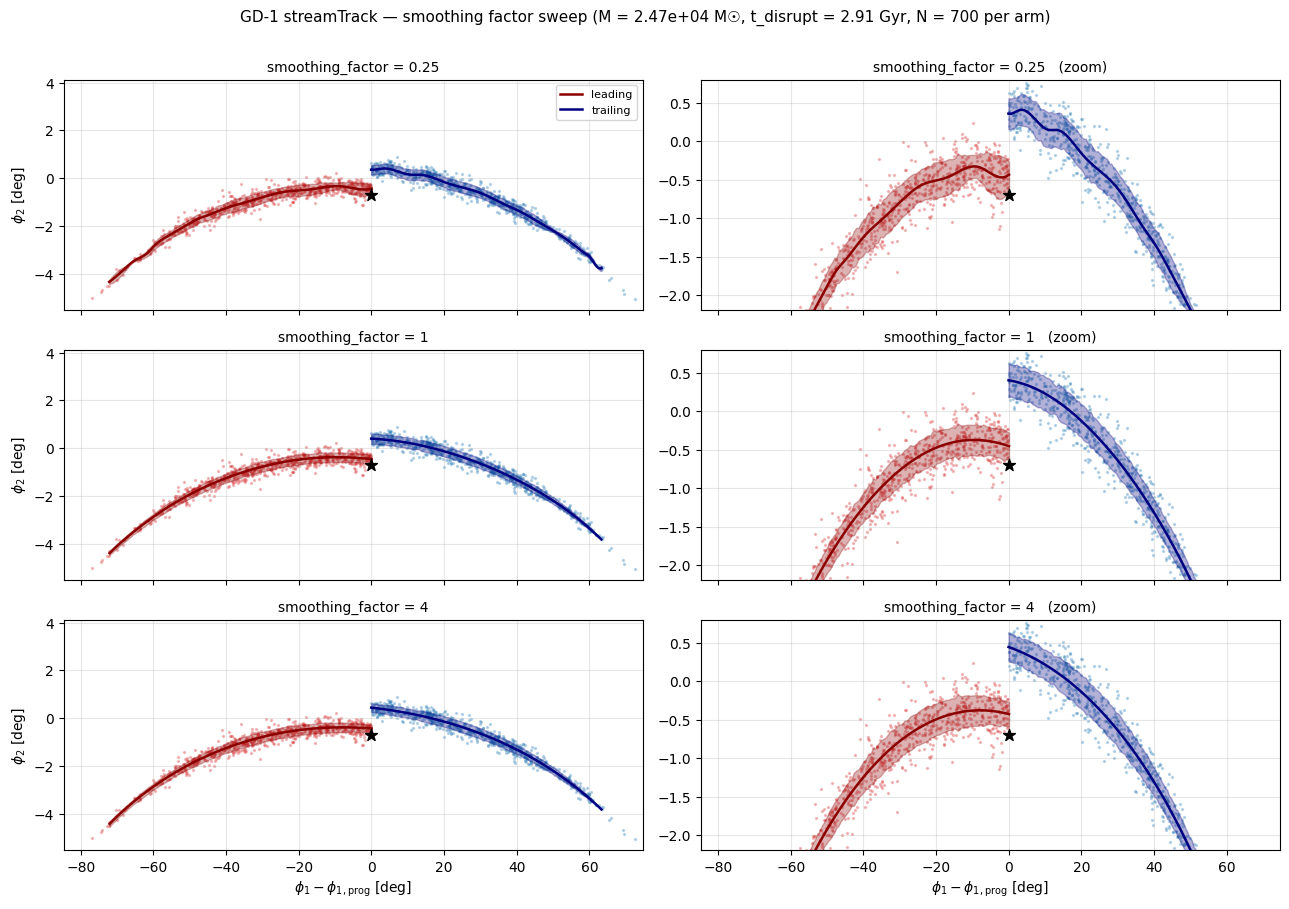

In [6]:
ncol, nrow = 2, len(SMOOTHING_FACTORS)
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.0 * nrow), sharex='col')

all_p1 = numpy.concatenate([phi1_l, phi1_t])
all_p2 = numpy.concatenate([phi2_l, phi2_t])
xlim = (numpy.nanmin(all_p1) - 2, numpy.nanmax(all_p1) + 2)
p2_med = numpy.nanmedian(all_p2)
p2_mad = numpy.nanmedian(numpy.abs(all_p2 - p2_med)) or 0.5
ylim_full = (p2_med - 6 * 1.48 * p2_mad, p2_med + 6 * 1.48 * p2_mad)
ylim_zoom = (p2_med - 1.5, p2_med + 1.5)

for i, f in enumerate(SMOOTHING_FACTORS):
    p1l, p2l, sl = curves_l[f]
    p1t, p2t, st = curves_t[f]
    for j, ylim in enumerate([ylim_full, ylim_zoom]):
        ax = axes[i, j]
        ax.scatter(phi1_l, phi2_l, s=2, c='tab:red', alpha=0.25, zorder=0)
        ax.scatter(phi1_t, phi2_t, s=2, c='tab:blue', alpha=0.25, zorder=0)
        ok_l = numpy.isfinite(sl)
        ok_t = numpy.isfinite(st)
        if ok_l.any():
            ax.fill_between(p1l[ok_l], (p2l - sl)[ok_l], (p2l + sl)[ok_l],
                            color='darkred', alpha=0.30, zorder=2)
            ax.plot(p1l[ok_l], p2l[ok_l], color='darkred', lw=1.8, zorder=3,
                    label='leading')
        if ok_t.any():
            ax.fill_between(p1t[ok_t], (p2t - st)[ok_t], (p2t + st)[ok_t],
                            color='navy', alpha=0.30, zorder=2)
            ax.plot(p1t[ok_t], p2t[ok_t], color='navy', lw=1.8, zorder=3,
                    label='trailing')
        ax.scatter([0.0], [p2_med], s=80, c='k', marker='*', zorder=5)
        ax.set_xlim(*xlim); ax.set_ylim(*ylim)
        ax.grid(alpha=0.3)
        if i == nrow - 1:
            ax.set_xlabel(r'$\phi_1 - \phi_{1,\rm prog}$ [deg]')
        if j == 0:
            ax.set_ylabel(r'$\phi_2$ [deg]')
        title = f'smoothing_factor = {f:g}'
        if j == 1:
            title += '   (zoom)'
        ax.set_title(title, fontsize=10)
        if i == 0 and j == 0:
            ax.legend(loc='upper right', fontsize=8)

fig.suptitle(f'GD-1 streamTrack — smoothing factor sweep '
             f'(M = {M_FIT:.2e} M☉, t_disrupt = {TDISRUPT_FIT:.2f} Gyr, '
             f'N = {N_PARTICLES} per arm)',
             fontsize=11, y=1.005)
fig.tight_layout()

## 5. Smoothing-amplitude diagnostic

The factor multiplies GCV's chosen `s` for every quantity in the fit.
Most series have negligible `s` (< 1e-7 — anywhere the particles aren't
intrinsically noisy), so the visual change is driven by the few series
with `s` of order 0.01–10. Below: the full leading-arm `smoothing_s`
array, multiplied by each factor.

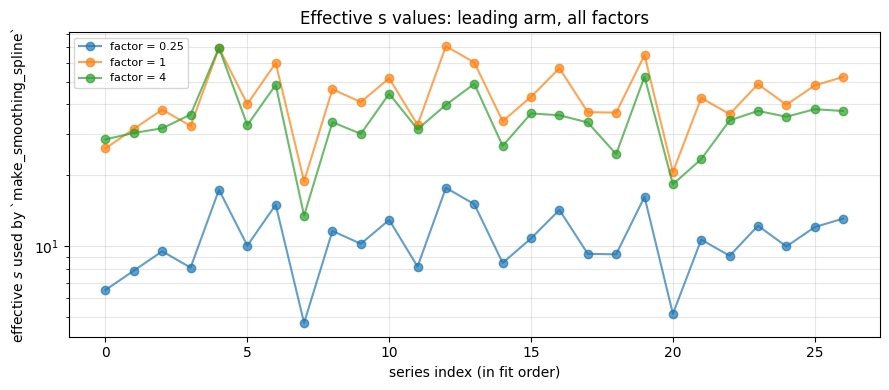

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
s1 = numpy.array(tracks_l[1.0].smoothing_s)
idx = numpy.arange(len(s1))
for f in SMOOTHING_FACTORS:
    s = numpy.array(tracks_l[f].smoothing_s)
    ax.plot(idx, numpy.maximum(s, 1e-16), 'o-', label=f'factor = {f:g}',
            alpha=0.7)
ax.set_yscale('log')
ax.set_xlabel('series index (in fit order)')
ax.set_ylabel(r'effective $s$ used by `make_smoothing_spline`')
ax.set_title('Effective s values: leading arm, all factors')
ax.legend(fontsize=8)
ax.grid(which='both', alpha=0.3)
fig.tight_layout()

## Takeaways

- The default factor `1.0` is well-calibrated after the y-rescaling
  fix in `_smooth_series`. The factor=1 panel is the recommended fit.
- factor `0.25` lets the mean track follow individual bin means and
  introduces visible wiggles at the bin scale.
- factor `4.0` looks essentially identical to factor `1.0` on the mean
  components — once GCV's fit already lies on the FITPACK
  minimum-knot floor, raising the chi² upper bound has no effect.
  The difference is more visible on the covariance entries (which set
  the band width).